In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("powerplant_data.csv")

In [4]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [5]:
df.isnull().sum()
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [6]:
X=df.drop(columns=["PE"])
y=df["PE"]

In [7]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [8]:
# Scaling

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [9]:
X_train_scaled.shape

(7654, 4)

In [10]:
import torch
import torch.nn as nn


tensors_Xtrain=torch.tensor(X_train_scaled,dtype=torch.float32)
tensors_ytrain=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1) # view 1D => 2D


tensors_Xtest=torch.tensor(X_test_scaled,dtype=torch.float32)
tensors_ytest=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [ ]:
op=torch.tensor(y_train.values,dtype=torch.float32)
op.shape

In [11]:
# view(-1,1) use

tensors_ytrain.shape
tensors_ytrain.shape

torch.Size([7654, 1])

In [13]:
from torch.utils.data import TensorDataset,DataLoader

In [14]:
train_dataset=TensorDataset(tensors_Xtrain,tensors_ytrain)
test_dataset=TensorDataset(tensors_Xtest,tensors_ytest)

In [15]:
train_dataset

In [16]:
# creating batches

training_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
testing_loader=DataLoader(test_dataset,batch_size=32)

In [17]:
# ready to give to ann model
training_loader

In [18]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model=nn.Sequential(
            # 1st layer 
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),
             # 2nd layer 
            nn.Linear(6,6),
            nn.ReLU(),
            #o/p layer

            nn.Linear(6,1),
        )


    def forward(self,x):
        return self.model(x)

In [19]:
import torch.optim as optim

model=ANN()

criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())


In [21]:
# training the model

epoches=100
train_losses=[]
val_losses=[]


for epoch in range(epoches):
    model.train()
    running_loss=0.0
    
    for xb,yb in training_loader:
        
            optimizer.zero_grad()
                
            outputs=model(xb)
            loss=criterion(outputs,yb)
                
            loss.backward()
            optimizer.step()
                
            running_loss+=loss.item()
                
        
    epoch_train_loss=running_loss/len(training_loader)
    train_losses.append(epoch_train_loss)                    
                        
    # Validation
    model.eval()
    running_val_loss=0.0
                        
    with torch.no_grad():
         for xb,yb in testing_loader:
            output=model(xb)
            loss=criterion(output,yb)
                        
            running_val_loss+=loss.item()
                        
                        
         epoch_val_loss=running_val_loss/len(testing_loader)
         val_losses.append(epoch_val_loss)               
         print(f"for epoch{epoch+1}/{epoches} training loss:{epoch_train_loss} val_loss :{epoch_val_loss}")                        
                        
                                

for epoch1/100 training loss:195979.7328125 val_loss :181898.62916666668
for epoch2/100 training loss:156156.5779296875 val_loss :125372.0703125
for epoch3/100 training loss:91009.99565429687 val_loss :61329.379622395834
for epoch4/100 training loss:43041.52347005208 val_loss :30792.425455729168
for epoch5/100 training loss:24602.814522298177 val_loss :20348.023307291667
for epoch6/100 training loss:17783.97268473307 val_loss :15566.79482421875
for epoch7/100 training loss:13831.763972981771 val_loss :11985.911059570313
for epoch8/100 training loss:10465.950002034506 val_loss :8785.26719563802
for epoch9/100 training loss:7385.296670532227 val_loss :5970.123921712239
for epoch10/100 training loss:4848.226624552409 val_loss :3788.4073893229165
for epoch11/100 training loss:3015.34009958903 val_loss :2332.729073079427
for epoch12/100 training loss:1849.4130884806316 val_loss :1446.6115509033202
for epoch13/100 training loss:1148.670965576172 val_loss :923.461538696289
for epoch14/100 tra

In [22]:
# Save our best model

best_epoch_loss=float("inf")

if epoch_val_loss<best_epoch_loss:
   best_epoch_loss=epoch_val_loss

   torch.save(model.state_dict(),"best model Learning params.pt")

Text(0, 0.5, 'loss')

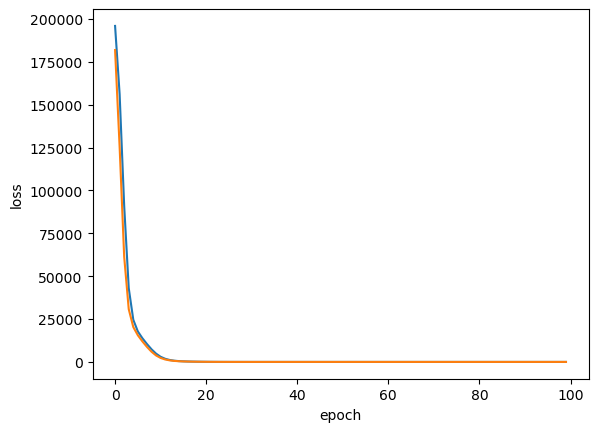

In [23]:
# plot 

import matplotlib.pyplot as plt


plt.plot(train_losses,label="training loss")
plt.plot(val_losses,label="validation loss")

plt.xlabel("epoch")
plt.ylabel("loss")

In [24]:
# Loading  the best model

best_model=model.load_state_dict(torch.load("best model Learning params.pt"))

In [25]:
# Evaluation

model.eval()
with torch.no_grad():
    train_pred=model(tensors_Xtrain)
    test_pred=model(tensors_Xtest)
    
    loss_train=criterion(train_pred,tensors_ytrain)
    loss_test=criterion(test_pred,tensors_ytest)
    
    
    print("MSE for training data",loss_train)
    print("MSE for testing data",loss_test)

MSE for training data tensor(20.7863)
MSE for testing data tensor(19.5401)


In [26]:
from sklearn.metrics import r2_score

print("R2_score Training:",r2_score(train_pred,tensors_ytrain))
print("R2_score Testing:",r2_score(tensors_ytest,test_pred))

R2_score Training: 0.9231957782338148
R2_score Testing: 0.9317122419675539


In [27]:
predicted_val=pd.DataFrame(test_pred.numpy(),columns=["predicted_val"])
Actual_val=pd.DataFrame(y_test.values,columns=["Actual_val"])

pd.concat([Actual_val,predicted_val],axis=1)

,Actual_val,predicted_val
0,433.27,435.996094
1,438.16,437.510834
2,458.42,461.437958
3,480.82,476.300598
4,441.41,435.771545
...,...,...
1909,456.70,451.863373
1910,438.04,432.289368
1911,467.80,468.109863
1912,437.14,431.704712


In [28]:
# both are tensors

predicted_val=pd.DataFrame(test_pred,columns=["predicted_val"])
Actual_val=pd.DataFrame(tensors_ytest,columns=["Actual_val"])

pd.concat([Actual_val,predicted_val],axis=1)

,Actual_val,predicted_val
0,433.269989,435.996094
1,438.160004,437.510834
2,458.420013,461.437958
3,480.820007,476.300598
4,441.410004,435.771545
...,...,...
1909,456.700012,451.863373
1910,438.040009,432.289368
1911,467.799988,468.109863
1912,437.140015,431.704712
